In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/green-supply-chain-dataset/green_supply_chain_dataset_1000.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error , mean_absolute_error


In [3]:
df = pd.read_csv('/kaggle/input/green-supply-chain-dataset/green_supply_chain_dataset_1000.csv')

In [4]:
df.head(10)

,ID,Product_Type,Raw_Material_Usage_kg,Energy_Consumption_kWh,Waste_Generated_kg,Transport_Distance_km,CO2_Emissions_kg,Manufacturing_Energy_kWh,Renewable_Energy_%,Cost_$,Delivery_Time_days,Sustainability_Score
0,1,Pharmaceutical,187.102474,372.345525,4.580997,2708.230192,206.072501,195.022097,77.312801,4696.896464,2,81.25
1,2,Food,117.375305,82.437951,31.494820,605.998543,794.003359,784.206729,31.899124,989.721787,4,37.55
2,3,Automotive,142.363657,82.065527,49.077714,945.366997,166.372969,775.047264,16.863118,1321.186084,2,41.17
3,4,Food,185.274882,55.448814,10.315275,2883.074057,653.161326,214.610271,46.877202,1464.672539,1,56.79
4,5,Food,144.375341,480.425629,39.837161,1552.152306,167.653725,309.596187,13.996935,381.536655,10,45.27
5,6,Apparel,38.982418,381.878762,45.487041,4697.747070,117.008856,170.108498,17.738022,790.650193,13,45.58
6,7,Automotive,119.494788,208.963134,47.241378,4111.827124,913.958029,290.202319,25.357257,4934.479630,13,16.49
7,8,Automotive,125.275859,183.441012,48.046645,4919.479312,230.622328,671.169053,42.504517,1713.040339,3,51.69
8,9,Automotive,90.584828,207.366453,26.551522,1372.387111,830.187647,364.820925,40.327565,753.445234,12,43.13
9,10,Food,149.924405,398.594089,48.888087,4851.645801,567.399328,161.877877,65.978430,713.558054,8,54.98


In [5]:
df.tail(10)

,ID,Product_Type,Raw_Material_Usage_kg,Energy_Consumption_kWh,Waste_Generated_kg,Transport_Distance_km,CO2_Emissions_kg,Manufacturing_Energy_kWh,Renewable_Energy_%,Cost_$,Delivery_Time_days,Sustainability_Score
990,991,Apparel,130.967240,482.282139,29.266012,4391.934132,306.148508,757.103511,33.935415,2579.933469,10,50.92
991,992,Automotive,126.647381,138.616567,23.735103,4535.965095,828.693153,663.565364,74.695290,3714.741988,12,55.56
992,993,Pharmaceutical,22.663888,478.143415,6.816746,2515.489161,999.382785,695.406138,11.707370,621.309988,7,31.90
993,994,Apparel,108.497524,497.668682,49.047843,1717.764157,250.859695,485.381710,50.699743,3407.267177,8,51.39
994,995,Food,38.532110,370.275263,11.520098,623.323450,301.912204,678.121758,48.425277,4499.898087,10,61.55
995,996,Apparel,150.112416,491.514679,4.294475,4771.674109,679.716798,312.452736,25.352428,477.383346,8,49.61
996,997,Electronics,107.322165,306.292901,30.147522,395.112030,967.176203,378.935133,40.022120,875.136028,13,37.19
997,998,Electronics,139.243278,166.793802,37.204467,1558.486360,920.023631,321.839110,55.658480,3639.833296,12,38.07
998,999,Pharmaceutical,17.917851,246.648149,2.589729,1560.524386,527.731744,427.171135,60.899184,2298.951912,8,68.98
999,1000,Automotive,26.110483,317.102421,33.277164,1669.966302,805.354768,299.905731,10.050180,2137.033380,10,23.28


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        1000 non-null   int64  
 1   Product_Type              1000 non-null   object 
 2   Raw_Material_Usage_kg     1000 non-null   float64
 3   Energy_Consumption_kWh    1000 non-null   float64
 4   Waste_Generated_kg        1000 non-null   float64
 5   Transport_Distance_km     1000 non-null   float64
 6   CO2_Emissions_kg          1000 non-null   float64
 7   Manufacturing_Energy_kWh  1000 non-null   float64
 8   Renewable_Energy_%        1000 non-null   float64
 9   Cost_$                    1000 non-null   float64
 10  Delivery_Time_days        1000 non-null   int64  
 11  Sustainability_Score      1000 non-null   float64
dtypes: float64(9), int64(2), object(1)
memory usage: 93.9+ KB


In [7]:
df.shape

(1000, 12)

In [8]:
df.isnull().sum()

ID                          0
Product_Type                0
Raw_Material_Usage_kg       0
Energy_Consumption_kWh      0
Waste_Generated_kg          0
Transport_Distance_km       0
CO2_Emissions_kg            0
Manufacturing_Energy_kWh    0
Renewable_Energy_%          0
Cost_$                      0
Delivery_Time_days          0
Sustainability_Score        0
dtype: int64

In [9]:
df.describe()

,ID,Raw_Material_Usage_kg,Energy_Consumption_kWh,Waste_Generated_kg,Transport_Distance_km,CO2_Emissions_kg,Manufacturing_Energy_kWh,Renewable_Energy_%,Cost_$,Delivery_Time_days,Sustainability_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,105.046415,274.277250,25.418835,2506.296581,523.203938,447.026783,44.153032,2502.760536,7.668000,51.207240
std,288.819436,55.616518,129.959635,14.103731,1401.083323,274.876548,202.134494,20.010416,1364.706793,4.027903,14.768154
min,1.000000,10.880084,50.060612,1.000570,100.150522,50.896245,100.999840,10.016870,201.166085,1.000000,12.800000
25%,250.750000,54.782690,166.916381,13.127740,1315.783701,286.755243,272.351083,26.836517,1311.317224,4.000000,40.155000
50%,500.500000,105.827254,274.697786,25.601655,2471.166625,511.160758,444.503275,44.008122,2388.768189,8.000000,50.795000
75%,750.250000,151.558389,388.052288,37.669786,3678.120070,760.403022,628.693850,60.430379,3642.199461,11.000000,61.830000
max,1000.000000,199.888608,499.256380,49.978327,4988.972006,999.382785,799.622477,79.923329,4980.861360,14.000000,91.530000


In [10]:
df.nunique()

ID                          1000
Product_Type                   5
Raw_Material_Usage_kg       1000
Energy_Consumption_kWh      1000
Waste_Generated_kg          1000
Transport_Distance_km       1000
CO2_Emissions_kg            1000
Manufacturing_Energy_kWh    1000
Renewable_Energy_%          1000
Cost_$                      1000
Delivery_Time_days            14
Sustainability_Score         925
dtype: int64

In [11]:
df.drop(columns='ID',inplace = True)
df


,Product_Type,Raw_Material_Usage_kg,Energy_Consumption_kWh,Waste_Generated_kg,Transport_Distance_km,CO2_Emissions_kg,Manufacturing_Energy_kWh,Renewable_Energy_%,Cost_$,Delivery_Time_days,Sustainability_Score
0,Pharmaceutical,187.102474,372.345525,4.580997,2708.230192,206.072501,195.022097,77.312801,4696.896464,2,81.25
1,Food,117.375305,82.437951,31.494820,605.998543,794.003359,784.206729,31.899124,989.721787,4,37.55
2,Automotive,142.363657,82.065527,49.077714,945.366997,166.372969,775.047264,16.863118,1321.186084,2,41.17
3,Food,185.274882,55.448814,10.315275,2883.074057,653.161326,214.610271,46.877202,1464.672539,1,56.79
4,Food,144.375341,480.425629,39.837161,1552.152306,167.653725,309.596187,13.996935,381.536655,10,45.27
...,...,...,...,...,...,...,...,...,...,...,...
995,Apparel,150.112416,491.514679,4.294475,4771.674109,679.716798,312.452736,25.352428,477.383346,8,49.61
996,Electronics,107.322165,306.292901,30.147522,395.112030,967.176203,378.935133,40.022120,875.136028,13,37.19
997,Electronics,139.243278,166.793802,37.204467,1558.486360,920.023631,321.839110,55.658480,3639.833296,12,38.07
998,Pharmaceutical,17.917851,246.648149,2.589729,1560.524386,527.731744,427.171135,60.899184,2298.951912,8,68.98


In [12]:
le = LabelEncoder()
df['Product_Type']=le.fit_transform(df['Product_Type'])
df

,Product_Type,Raw_Material_Usage_kg,Energy_Consumption_kWh,Waste_Generated_kg,Transport_Distance_km,CO2_Emissions_kg,Manufacturing_Energy_kWh,Renewable_Energy_%,Cost_$,Delivery_Time_days,Sustainability_Score
0,4,187.102474,372.345525,4.580997,2708.230192,206.072501,195.022097,77.312801,4696.896464,2,81.25
1,3,117.375305,82.437951,31.494820,605.998543,794.003359,784.206729,31.899124,989.721787,4,37.55
2,1,142.363657,82.065527,49.077714,945.366997,166.372969,775.047264,16.863118,1321.186084,2,41.17
3,3,185.274882,55.448814,10.315275,2883.074057,653.161326,214.610271,46.877202,1464.672539,1,56.79
4,3,144.375341,480.425629,39.837161,1552.152306,167.653725,309.596187,13.996935,381.536655,10,45.27
...,...,...,...,...,...,...,...,...,...,...,...
995,0,150.112416,491.514679,4.294475,4771.674109,679.716798,312.452736,25.352428,477.383346,8,49.61
996,2,107.322165,306.292901,30.147522,395.112030,967.176203,378.935133,40.022120,875.136028,13,37.19
997,2,139.243278,166.793802,37.204467,1558.486360,920.023631,321.839110,55.658480,3639.833296,12,38.07
998,4,17.917851,246.648149,2.589729,1560.524386,527.731744,427.171135,60.899184,2298.951912,8,68.98


<Axes: >

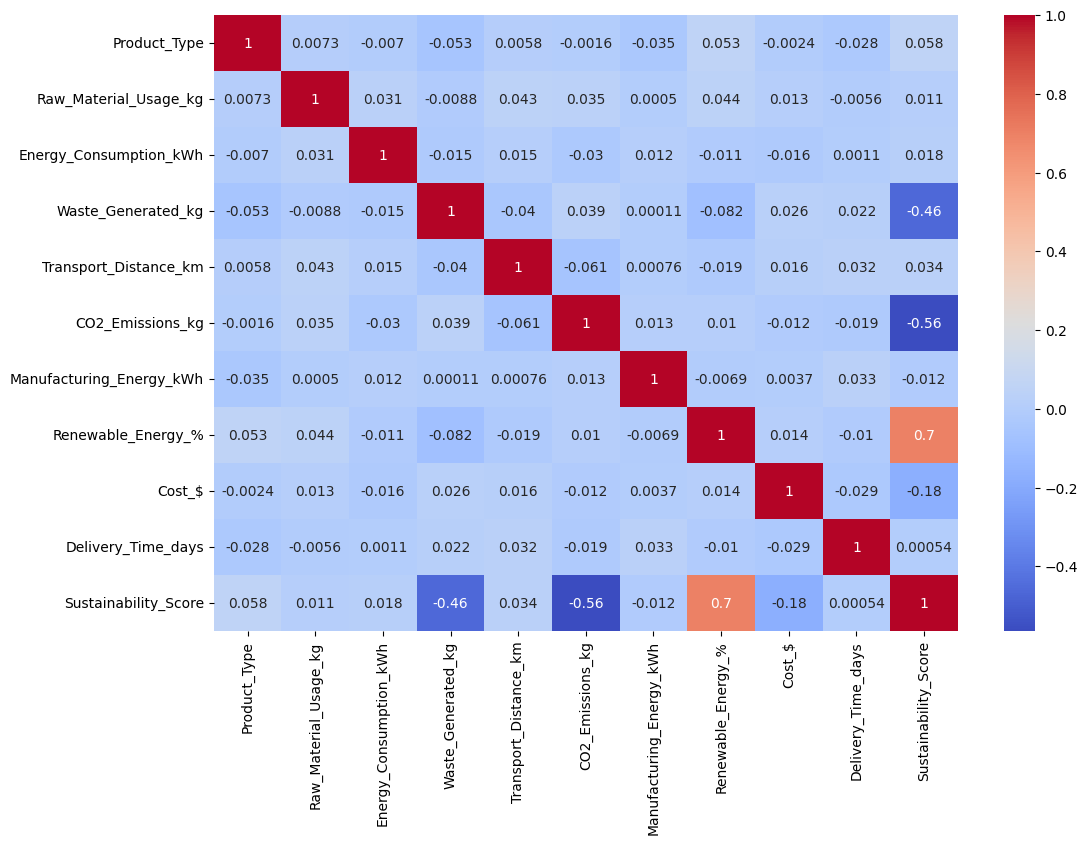

In [13]:
plt.figure(figsize =(12,8))
sns.heatmap(df.corr(), cmap = 'coolwarm', annot = True)

In [14]:
X = df.drop(columns='Sustainability_Score').values
Y = df['Sustainability_Score'].values

In [15]:
x_train , x_test, y_train, y_test = train_test_split(X,Y, test_size = 0.5, random_state = 42)


In [16]:
lr = LinearRegression()
lr.fit(x_train, y_train)


LinearRegression()

In [17]:
y_pred = lr.predict(x_test)
print(y_pred)

[51.02165869 44.12273827 79.83490611 57.54277076 49.31870603 51.54687788
 31.44781704 24.33402694 77.04866292 42.9785437  51.18095376 52.27406298
 34.73290978 57.94948224 37.92923291 71.20928864 40.8772839  50.49177187
 44.24167409 56.61461127 35.48259187 39.22976246 66.37667422 43.15804695
 34.21356326 43.11074713 44.09090565 73.30788801 23.87819872 43.37379031
 55.58894384 64.85935741 41.7642185  83.7253652  68.15850073 89.54410985
 32.34513015 59.2269511  56.52836098 54.71345858 33.95495652 55.06003617
 53.02451344 49.1299447  49.08516982 50.97353215 69.37181685 60.09661708
 69.20920144 80.94831464 51.8862861  73.33942105 59.69713525 31.58702946
 69.42546808 26.55413889 78.70219143 64.61183323 42.41108667 28.80800065
 49.60550248 26.89040795 43.52977549 53.56068347 51.93383662 63.45319062
 19.90414474 65.43262204 54.31730417 60.84239005 60.57386332 62.76523595
 39.18307407 34.50105541 45.18039782 29.27946034 57.19867587 43.28921942
 37.57265434 65.73238042 45.93617063 75.53679847 40

In [18]:
print(r2_score(y_pred, y_test))

0.9999999635037609


In [19]:
print(mean_squared_error(y_pred, y_test))
print( mean_absolute_error(y_pred, y_test))

8.11561735472284e-06
0.0024637545517350572


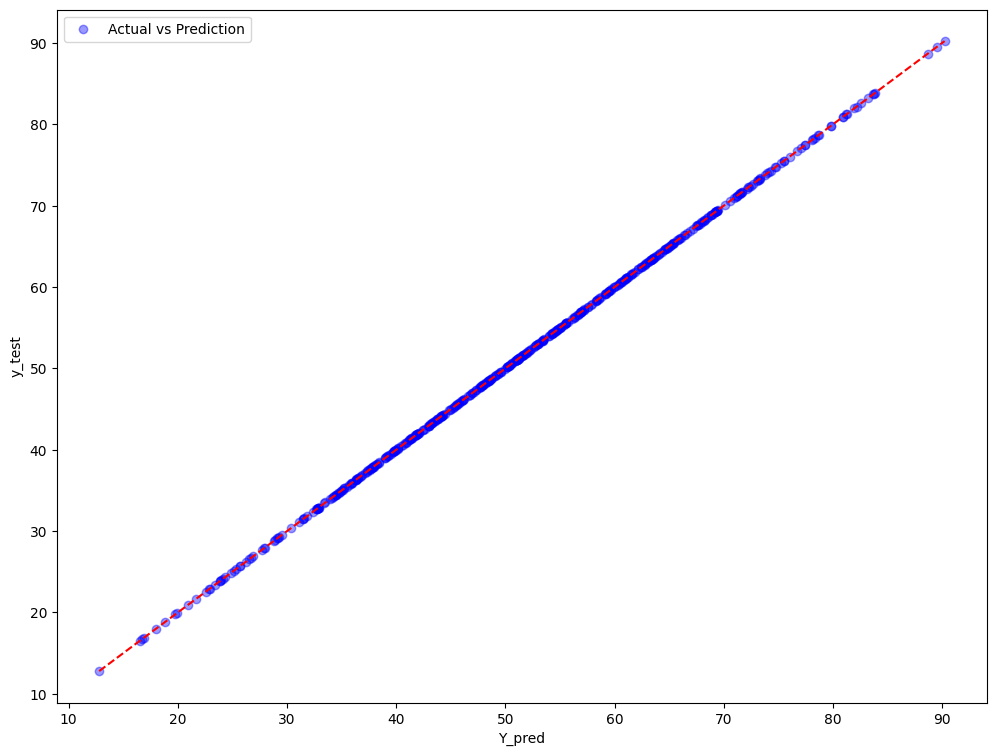

In [20]:
plt.figure(figsize =(12,9))
plt.scatter(y_pred, y_test, alpha = 0.4,color = 'blue' ,label = 'Actual vs Prediction')
y_min = min(y_pred.min(), y_test.min()) 
y_max = max(y_pred.max(), y_test.max()) 
plt.plot([y_min,y_max], [y_min,y_max], color = 'red', linestyle = '--')
plt.xlabel("Y_pred")
plt.ylabel('y_test')
plt.legend()
plt.show()